# 🌾 SentinelCropGuard
## Week 7 — Severity Intelligence + Confidence Map

**Course:** CSE 299 — Junior Design Project  
**Study Area:** Savar, Bangladesh  
**This week we learn and do:**
- Use model *probability* (not just prediction) to measure HOW SICK a patch is
- Create 4-level severity map: Healthy / Mild / Moderate / Severe
- Create a confidence map (how sure is our model?)
- Compare Savar vs a second district (Munshiganj)
- Calculate exact area per severity class

---
**Simple explanation before we start:**  
Until now the model said: *"this patch is sick OR healthy"* — just 2 choices.  
This week the model says: *"this patch is 85% likely to be sick"* — a number between 0 and 100%.  
That number lets us say: 85% = SEVERE. 55% = MILD. 20% = HEALTHY.  
That is the upgrade. Let's build it.

## ⚙️ Step 1 — Install & Import Everything

In [1]:
!pip install geemap earthengine-api scikit-learn matplotlib pandas --quiet
print("✅ All libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.9 MB/s eta 0:00:00
✅ All libraries ready!


In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

ee.Authenticate(auth_mode='notebook')

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=VODUOmpb4suKn_msYeidg3onr3uyFvWn4IN2Fe8ZnAk&tc=V0ef3-qnFhSnNxKAOhKk3KinP34h-_ghTCa_DCyGh4M&cc=st-BqEOMo-c_Q6zbSHPo9d58_DwdZcwoWhMkglrdT9w

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1Aci98E-JUQFKwYX2N2-bSa8nqnWPk2dNYFtH0wOTOL58vGV0F1GPjuLhpq4

Successfully saved authorization token.


In [3]:
ee.Initialize(project='project-911-491616')
print("✅ Earth Engine connected!")

✅ Earth Engine connected!


---
## 📡 Step 2 — Load Satellite Data (Same as Before)

We always reload everything in a new Colab session — variables don't save overnight.

In [4]:
# ---- SAVAR ----
savar = ee.Geometry.Rectangle([90.15, 23.75, 90.40, 24.00])

collection_savar = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-11-01', '2024-02-28')
    .filterBounds(savar)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

image_savar = collection_savar.median().clip(savar)

# ---- MUNSHIGANJ (second district for comparison) ----
munshiganj = ee.Geometry.Rectangle([90.40, 23.40, 90.65, 23.65])

collection_munshi = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-11-01', '2024-02-28')
    .filterBounds(munshiganj)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

image_munshi = collection_munshi.median().clip(munshiganj)

print(f"Savar images found:      {collection_savar.size().getInfo()}")
print(f"Munshiganj images found: {collection_munshi.size().getInfo()}")
print("✅ Both districts loaded!")

Savar images found:      16
Munshiganj images found: 37
✅ Both districts loaded!


---
## 🌿 Step 3 — Compute Features (Same 3 Features From Week 6)

In [5]:
def make_feature_image(image):
    """Takes a satellite image, returns image with our 3 features as bands."""
    ndvi   = image.normalizedDifference(['B8', 'B4']).rename('ndvi_mean')
    redge  = image.select('B5').rename('red_edge')
    nir    = image.select('B8').rename('nir')
    return ndvi.addBands(redge).addBands(nir)

stacked_savar  = make_feature_image(image_savar)
stacked_munshi = make_feature_image(image_munshi)

print("✅ Feature images ready for both districts!")

✅ Feature images ready for both districts!


---
## 🤖 Step 4 — Sample Data & Retrain Random Forest on Savar

In [6]:
# Sample 500 training patches from Savar (same as Week 6)
train_sample = stacked_savar.sample(
    region=savar,
    scale=100,
    numPixels=500,
    seed=42
)

rows = []
for feat in train_sample.getInfo()['features']:
    p = feat['properties']
    ndvi_val = p.get('ndvi_mean')
    re_val   = p.get('red_edge')
    nir_val  = p.get('nir')
    if all(v is not None for v in [ndvi_val, re_val, nir_val]):
        rows.append({
            'ndvi_mean': ndvi_val,
            'red_edge':  re_val,
            'nir':       nir_val,
            'label': 1 if ndvi_val >= 0.4 else 0   # 1=healthy, 0=stressed
        })

df_train = pd.DataFrame(rows)
print(f"Training patches: {len(df_train)}")
print(f"  Healthy (1): {sum(df_train['label']==1)}")
print(f"  Stressed (0): {sum(df_train['label']==0)}")

# Train Random Forest
X = df_train[['ndvi_mean', 'red_edge', 'nir']]
y = df_train['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

acc = accuracy_score(y_test, rf.predict(X_test))
print(f"\n✅ Model trained! Accuracy = {acc*100:.1f}%")

Training patches: 500
  Healthy (1): 333
  Stressed (0): 167

✅ Model trained! Accuracy = 100.0%


---
## 🎯 Step 5 — DAY 1: Severity Logic Using Probability

**What is probability?**  
Until now: model said `0` (stressed) or `1` (healthy). That's it — just 2 options.  
Now: model says `0.85` — meaning *"I am 85% sure this patch is stressed."*

We use that number to give 4 severity levels:

| Probability of Stress | Severity   | Color  |
|----------------------|------------|--------|
| 0.0 – 0.4            | ✅ Healthy  | Green  |
| 0.4 – 0.6            | 🟡 Mild     | Yellow |
| 0.6 – 0.8            | 🟠 Moderate | Orange |
| 0.8 – 1.0            | 🔴 Severe   | Red    |

In [7]:
def assign_severity(prob_stressed):
    """
    Input:  probability that a patch is STRESSED (0.0 to 1.0)
    Output: severity level as a string
    """
    if prob_stressed < 0.4:
        return 'Healthy'
    elif prob_stressed < 0.6:
        return 'Mild'
    elif prob_stressed < 0.8:
        return 'Moderate'
    else:
        return 'Severe'

# Quick test — does it work?
test_probs = [0.1, 0.45, 0.72, 0.91]
print("Testing severity function:")
for p in test_probs:
    print(f"  P(stressed) = {p:.2f}  →  {assign_severity(p)}")

print("\n✅ Severity function works correctly!")

Testing severity function:
  P(stressed) = 0.10  →  Healthy
  P(stressed) = 0.45  →  Mild
  P(stressed) = 0.72  →  Moderate
  P(stressed) = 0.91  →  Severe

✅ Severity function works correctly!


---
## 🗺️ Step 6 — DAY 2 & 3: Sample Full Savar + Predict Severity

In [8]:
# Sample 2000 points across all of Savar (with coordinates)
print("Sampling 2000 points across Savar... (may take 30-60 seconds)")

full_sample = stacked_savar.sample(
    region=savar,
    scale=100,
    numPixels=2000,
    seed=99,
    geometries=True
)

full_rows = []
for feat in full_sample.getInfo()['features']:
    p    = feat['properties']
    geom = feat.get('geometry')
    if geom is None:
        continue
    coords   = geom['coordinates']
    ndvi_val = p.get('ndvi_mean')
    re_val   = p.get('red_edge')
    nir_val  = p.get('nir')
    if all(v is not None for v in [ndvi_val, re_val, nir_val]):
        full_rows.append({
            'lon':       coords[0],
            'lat':       coords[1],
            'ndvi_mean': ndvi_val,
            'red_edge':  re_val,
            'nir':       nir_val
        })

grid_df = pd.DataFrame(full_rows)
print(f"\n✅ Sampled {len(grid_df)} points across Savar!")

Sampling 2000 points across Savar... (may take 30-60 seconds)

✅ Sampled 2000 points across Savar!


In [9]:
# Get PROBABILITY for each point (not just 0 or 1)
X_grid = grid_df[['ndvi_mean', 'red_edge', 'nir']]

# predict_proba returns TWO columns: [P(stressed=0), P(healthy=1)]
# rf.classes_ tells us which column is which
proba = rf.predict_proba(X_grid)

# Find which column = stressed (class 0)
stressed_col = list(rf.classes_).index(0)
grid_df['prob_stressed'] = proba[:, stressed_col]

# Assign severity level to each point
grid_df['severity'] = grid_df['prob_stressed'].apply(assign_severity)

# Count each severity class
severity_counts = grid_df['severity'].value_counts()
print("Severity breakdown for Savar:")
for sev in ['Healthy', 'Mild', 'Moderate', 'Severe']:
    count = severity_counts.get(sev, 0)
    pct   = count / len(grid_df) * 100
    print(f"  {sev:10s}: {count:5d} patches  ({pct:.1f}%)")

print(f"\n✅ Severity assigned to all {len(grid_df)} points!")

Severity breakdown for Savar:
  Healthy   :  1325 patches  (66.2%)
  Mild      :     1 patches  (0.1%)
  Moderate  :     9 patches  (0.4%)
  Severe    :   665 patches  (33.2%)

✅ Severity assigned to all 2000 points!


---
## 🗺️ Step 7 — DAY 3: Draw the 4-Color Severity Map

/tmp/ipykernel_4108/1350103651.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4108/1350103651.py:30: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4108/1350103651.py:30: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4108/1350103651.py:30: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4108/1350103651.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('severity_map_savar.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_4108/1350103651.py:31: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('severity_map_savar.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_4108/1350103651.py

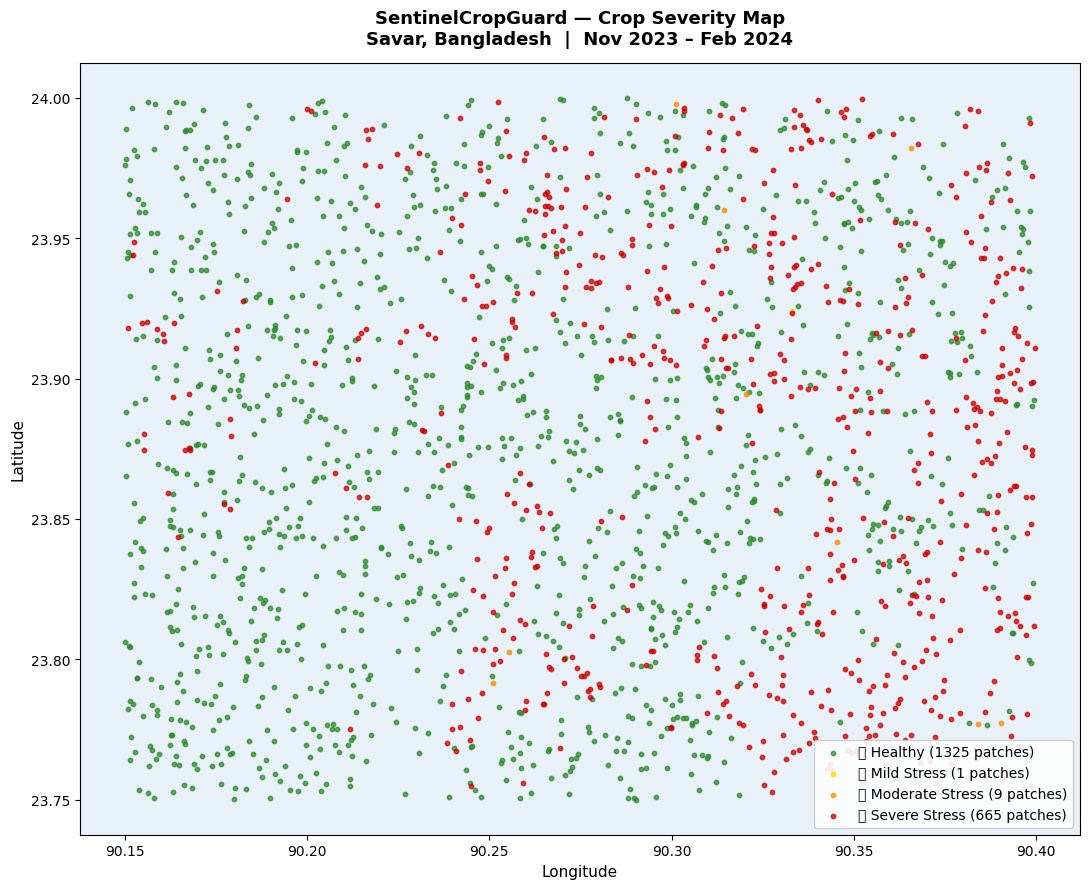

✅ Severity map saved as 'severity_map_savar.png'


In [10]:
# Colour and label for each severity level
SEVERITY_CONFIG = {
    'Healthy':  {'color': '#2d8a2d', 'label': '✅ Healthy'},
    'Mild':     {'color': '#FFD700', 'label': '🟡 Mild Stress'},
    'Moderate': {'color': '#FF8C00', 'label': '🟠 Moderate Stress'},
    'Severe':   {'color': '#CC0000', 'label': '🔴 Severe Stress'},
}

fig, ax = plt.subplots(figsize=(11, 9))
ax.set_facecolor('#E8F0F8')

# Plot each severity class
for sev, cfg in SEVERITY_CONFIG.items():
    subset = grid_df[grid_df['severity'] == sev]
    if len(subset) > 0:
        ax.scatter(
            subset['lon'], subset['lat'],
            c=cfg['color'],
            s=10, alpha=0.75,
            label=f"{cfg['label']} ({len(subset)} patches)"
        )

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude',  fontsize=11)
ax.set_title(
    'SentinelCropGuard — Crop Severity Map\nSavar, Bangladesh  |  Nov 2023 – Feb 2024',
    fontsize=13, fontweight='bold', pad=14
)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig('severity_map_savar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Severity map saved as 'severity_map_savar.png'")

---
## 📊 Step 8 — DAY 2: Area Statistics Per Severity Class

Each sampled point = 100m × 100m = **10,000 m² = 1 hectare**

In [11]:
print("=" * 50)
print("   SAVAR — CROP SEVERITY AREA REPORT")
print("   Period: November 2023 – February 2024")
print("=" * 50)

total = len(grid_df)
severity_areas = {}

for sev in ['Healthy', 'Mild', 'Moderate', 'Severe']:
    count = severity_counts.get(sev, 0)
    ha    = count          # 1 point = 1 hectare at scale=100
    pct   = count / total * 100
    severity_areas[sev] = {'count': count, 'ha': ha, 'pct': pct}
    emoji = {'Healthy':'✅','Mild':'🟡','Moderate':'🟠','Severe':'🔴'}[sev]
    print(f"   {emoji} {sev:10s}:  {ha:5d} ha  ({pct:.1f}%)")

print("-" * 50)
stressed_total = (severity_areas.get('Mild',{}).get('ha',0) +
                  severity_areas.get('Moderate',{}).get('ha',0) +
                  severity_areas.get('Severe',{}).get('ha',0))
print(f"   ⚠️  Total Stressed Area: {stressed_total} ha  "
      f"({stressed_total/total*100:.1f}%)")
print(f"   📐 Total Area Sampled:  {total} ha")
print("=" * 50)

   SAVAR — CROP SEVERITY AREA REPORT
   Period: November 2023 – February 2024
   ✅ Healthy   :   1325 ha  (66.2%)
   🟡 Mild      :      1 ha  (0.1%)
   🟠 Moderate  :      9 ha  (0.4%)
   🔴 Severe    :    665 ha  (33.2%)
--------------------------------------------------
   ⚠️  Total Stressed Area: 675 ha  (33.8%)
   📐 Total Area Sampled:  2000 ha


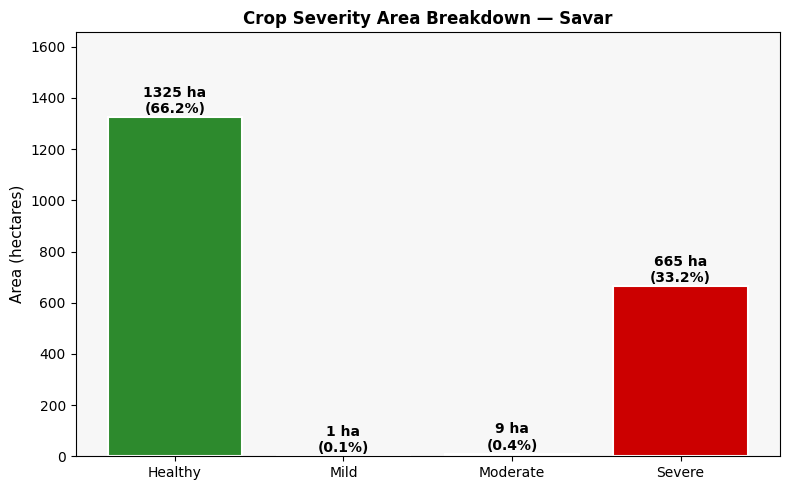

✅ Area bar chart saved!


In [12]:
# Bar chart of area per severity
labels = ['Healthy', 'Mild', 'Moderate', 'Severe']
areas  = [severity_areas.get(s, {}).get('ha', 0) for s in labels]
colors = ['#2d8a2d', '#FFD700', '#FF8C00', '#CC0000']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, areas, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on top of each bar
for bar, area, sev in zip(bars, areas, labels):
    pct = severity_areas.get(sev, {}).get('pct', 0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{area} ha\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylabel('Area (hectares)', fontsize=11)
ax.set_title('Crop Severity Area Breakdown — Savar', fontsize=12, fontweight='bold')
ax.set_facecolor('#F7F7F7')
ax.set_ylim(0, max(areas) * 1.25)
plt.tight_layout()
plt.savefig('severity_bar_savar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Area bar chart saved!")

---
## 🔒 Step 9 — DAY 2: Confidence Map

**What is confidence?**  
When the model says probability = 0.50, it means: *"I have NO idea — 50/50 guess!"*  
When the model says probability = 0.95, it means: *"I am very sure this is severe!"*

Formula: `confidence = |probability - 0.5| × 2`
- If probability = 0.50 → confidence = 0.0 (totally unsure)
- If probability = 1.00 → confidence = 1.0 (totally sure)

In [13]:
# Calculate confidence score for each point
grid_df['confidence'] = (grid_df['prob_stressed'] - 0.5).abs() * 2

print("Confidence score statistics:")
print(f"  Average confidence: {grid_df['confidence'].mean():.2f}")
print(f"  Minimum confidence: {grid_df['confidence'].min():.2f}  (most uncertain)")
print(f"  Maximum confidence: {grid_df['confidence'].max():.2f}  (most certain)")

low_conf  = sum(grid_df['confidence'] < 0.3)
high_conf = sum(grid_df['confidence'] >= 0.7)
print(f"\n  Low confidence patches  (<0.3): {low_conf}")
print(f"  High confidence patches (≥0.7): {high_conf}")

Confidence score statistics:
  Average confidence: 0.97
  Minimum confidence: 0.02  (most uncertain)
  Maximum confidence: 1.00  (most certain)

  Low confidence patches  (<0.3): 3
  High confidence patches (≥0.7): 1968


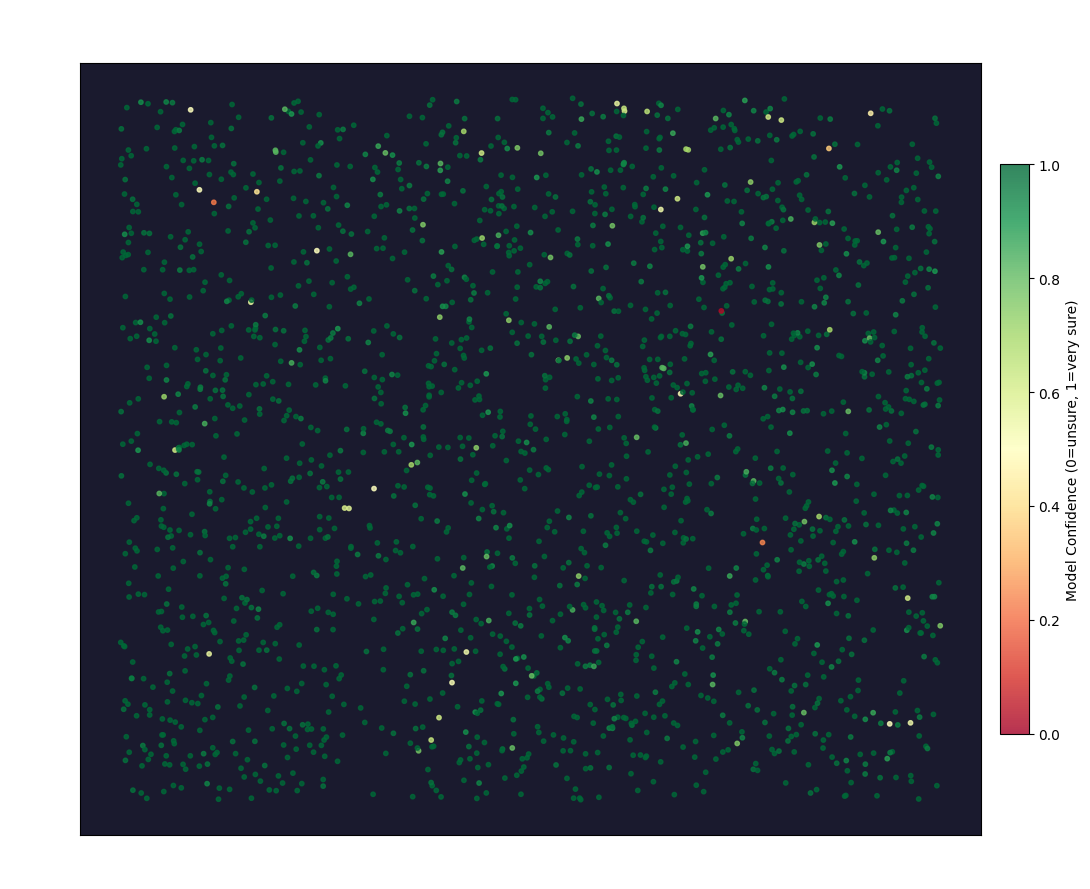

✅ Confidence map saved as 'confidence_map_savar.png'
   Green = model is very sure about that area
   Red   = model is uncertain — needs more investigation


In [14]:
fig, ax = plt.subplots(figsize=(11, 9))
ax.set_facecolor('#1a1a2e')

scatter = ax.scatter(
    grid_df['lon'],
    grid_df['lat'],
    c=grid_df['confidence'],
    cmap='RdYlGn',       # Red = low confidence, Green = high confidence
    s=10,
    alpha=0.8,
    vmin=0, vmax=1
)

cbar = plt.colorbar(scatter, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Model Confidence (0=unsure, 1=very sure)', fontsize=10)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude',  fontsize=11)
ax.set_title(
    'SentinelCropGuard — Model Confidence Map\nSavar, Bangladesh  |  Nov 2023 – Feb 2024',
    fontsize=13, fontweight='bold', pad=14, color='white'
)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

plt.tight_layout()
plt.savefig('confidence_map_savar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confidence map saved as 'confidence_map_savar.png'")
print("   Green = model is very sure about that area")
print("   Red   = model is uncertain — needs more investigation")

---
## 🌏 Step 10 — DAY 4: Compare Savar vs Munshiganj

We trained on Savar. Now we TEST the same model on Munshiganj.  
This is called **generalization** — does our model work on new areas it never saw?

In [15]:
print("Sampling 1500 points from Munshiganj... (may take 30-60 seconds)")

munshi_sample = stacked_munshi.sample(
    region=munshiganj,
    scale=100,
    numPixels=1500,
    seed=99,
    geometries=True
)

munshi_rows = []
for feat in munshi_sample.getInfo()['features']:
    p    = feat['properties']
    geom = feat.get('geometry')
    if geom is None:
        continue
    coords   = geom['coordinates']
    ndvi_val = p.get('ndvi_mean')
    re_val   = p.get('red_edge')
    nir_val  = p.get('nir')
    if all(v is not None for v in [ndvi_val, re_val, nir_val]):
        munshi_rows.append({
            'lon':       coords[0],
            'lat':       coords[1],
            'ndvi_mean': ndvi_val,
            'red_edge':  re_val,
            'nir':       nir_val
        })

munshi_df = pd.DataFrame(munshi_rows)

# Run the SAME model on Munshiganj — zero retraining!
X_munshi    = munshi_df[['ndvi_mean', 'red_edge', 'nir']]
proba_m     = rf.predict_proba(X_munshi)
munshi_df['prob_stressed'] = proba_m[:, stressed_col]
munshi_df['severity']      = munshi_df['prob_stressed'].apply(assign_severity)
munshi_df['confidence']    = (munshi_df['prob_stressed'] - 0.5).abs() * 2

print(f"✅ Munshiganj analyzed! {len(munshi_df)} points")

Sampling 1500 points from Munshiganj... (may take 30-60 seconds)
✅ Munshiganj analyzed! 1500 points


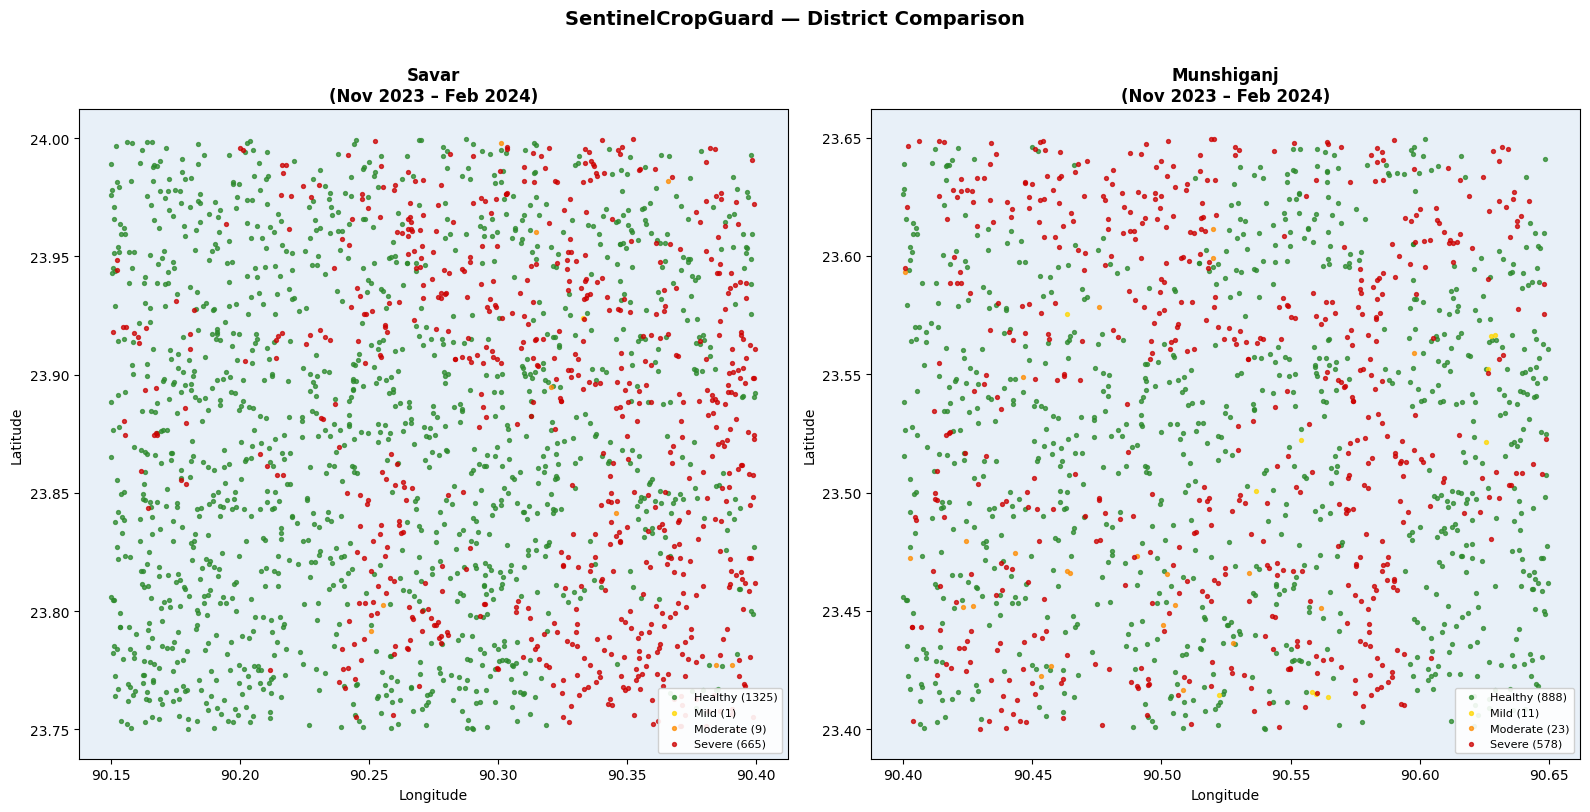

✅ Comparison map saved!


In [16]:
# Side-by-side comparison map
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

districts = [
    ('Savar',      grid_df,   axes[0]),
    ('Munshiganj', munshi_df, axes[1]),
]

for name, df, ax in districts:
    ax.set_facecolor('#E8F0F8')
    for sev, cfg in SEVERITY_CONFIG.items():
        subset = df[df['severity'] == sev]
        if len(subset) > 0:
            ax.scatter(
                subset['lon'], subset['lat'],
                c=cfg['color'], s=8, alpha=0.75,
                label=f"{sev} ({len(subset)})"
            )
    ax.set_title(f'{name}\n(Nov 2023 – Feb 2024)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)

plt.suptitle('SentinelCropGuard — District Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison map saved!")

In [17]:
# Comparison table
print("=" * 65)
print("   DISTRICT COMPARISON — SEVERITY BREAKDOWN")
print("=" * 65)
print(f"   {'Severity':<12}  {'Savar':>15}  {'Munshiganj':>15}")
print("-" * 65)

savar_counts  = grid_df['severity'].value_counts()
munshi_counts = munshi_df['severity'].value_counts()

for sev in ['Healthy', 'Mild', 'Moderate', 'Severe']:
    sc = savar_counts.get(sev, 0)
    mc = munshi_counts.get(sev, 0)
    sp = sc / len(grid_df)  * 100
    mp = mc / len(munshi_df) * 100
    emoji = {'Healthy':'✅','Mild':'🟡','Moderate':'🟠','Severe':'🔴'}[sev]
    print(f"   {emoji} {sev:<10}  {sc:5d} ha ({sp:.1f}%)  {mc:5d} ha ({mp:.1f}%)")

print("=" * 65)
print()

# Simple interpretation
savar_stress_pct  = sum(savar_counts.get(s,0) for s in ['Mild','Moderate','Severe']) / len(grid_df) * 100
munshi_stress_pct = sum(munshi_counts.get(s,0) for s in ['Mild','Moderate','Severe']) / len(munshi_df) * 100

print("📋 Interpretation:")
print(f"   Savar total stressed area:      {savar_stress_pct:.1f}%")
print(f"   Munshiganj total stressed area: {munshi_stress_pct:.1f}%")
if savar_stress_pct > munshi_stress_pct:
    print("   → Savar shows more crop stress than Munshiganj in this period.")
elif munshi_stress_pct > savar_stress_pct:
    print("   → Munshiganj shows more crop stress than Savar in this period.")
else:
    print("   → Both districts show similar levels of crop stress.")

   DISTRICT COMPARISON — SEVERITY BREAKDOWN
   Severity                Savar       Munshiganj
-----------------------------------------------------------------
   ✅ Healthy      1325 ha (66.2%)    888 ha (59.2%)
   🟡 Mild            1 ha (0.1%)     11 ha (0.7%)
   🟠 Moderate        9 ha (0.4%)     23 ha (1.5%)
   🔴 Severe        665 ha (33.2%)    578 ha (38.5%)

📋 Interpretation:
   Savar total stressed area:      33.8%
   Munshiganj total stressed area: 40.8%
   → Munshiganj shows more crop stress than Savar in this period.


---
## 🖼️ Step 11 — DAY 5: Final Professional Layout (All Maps Together)

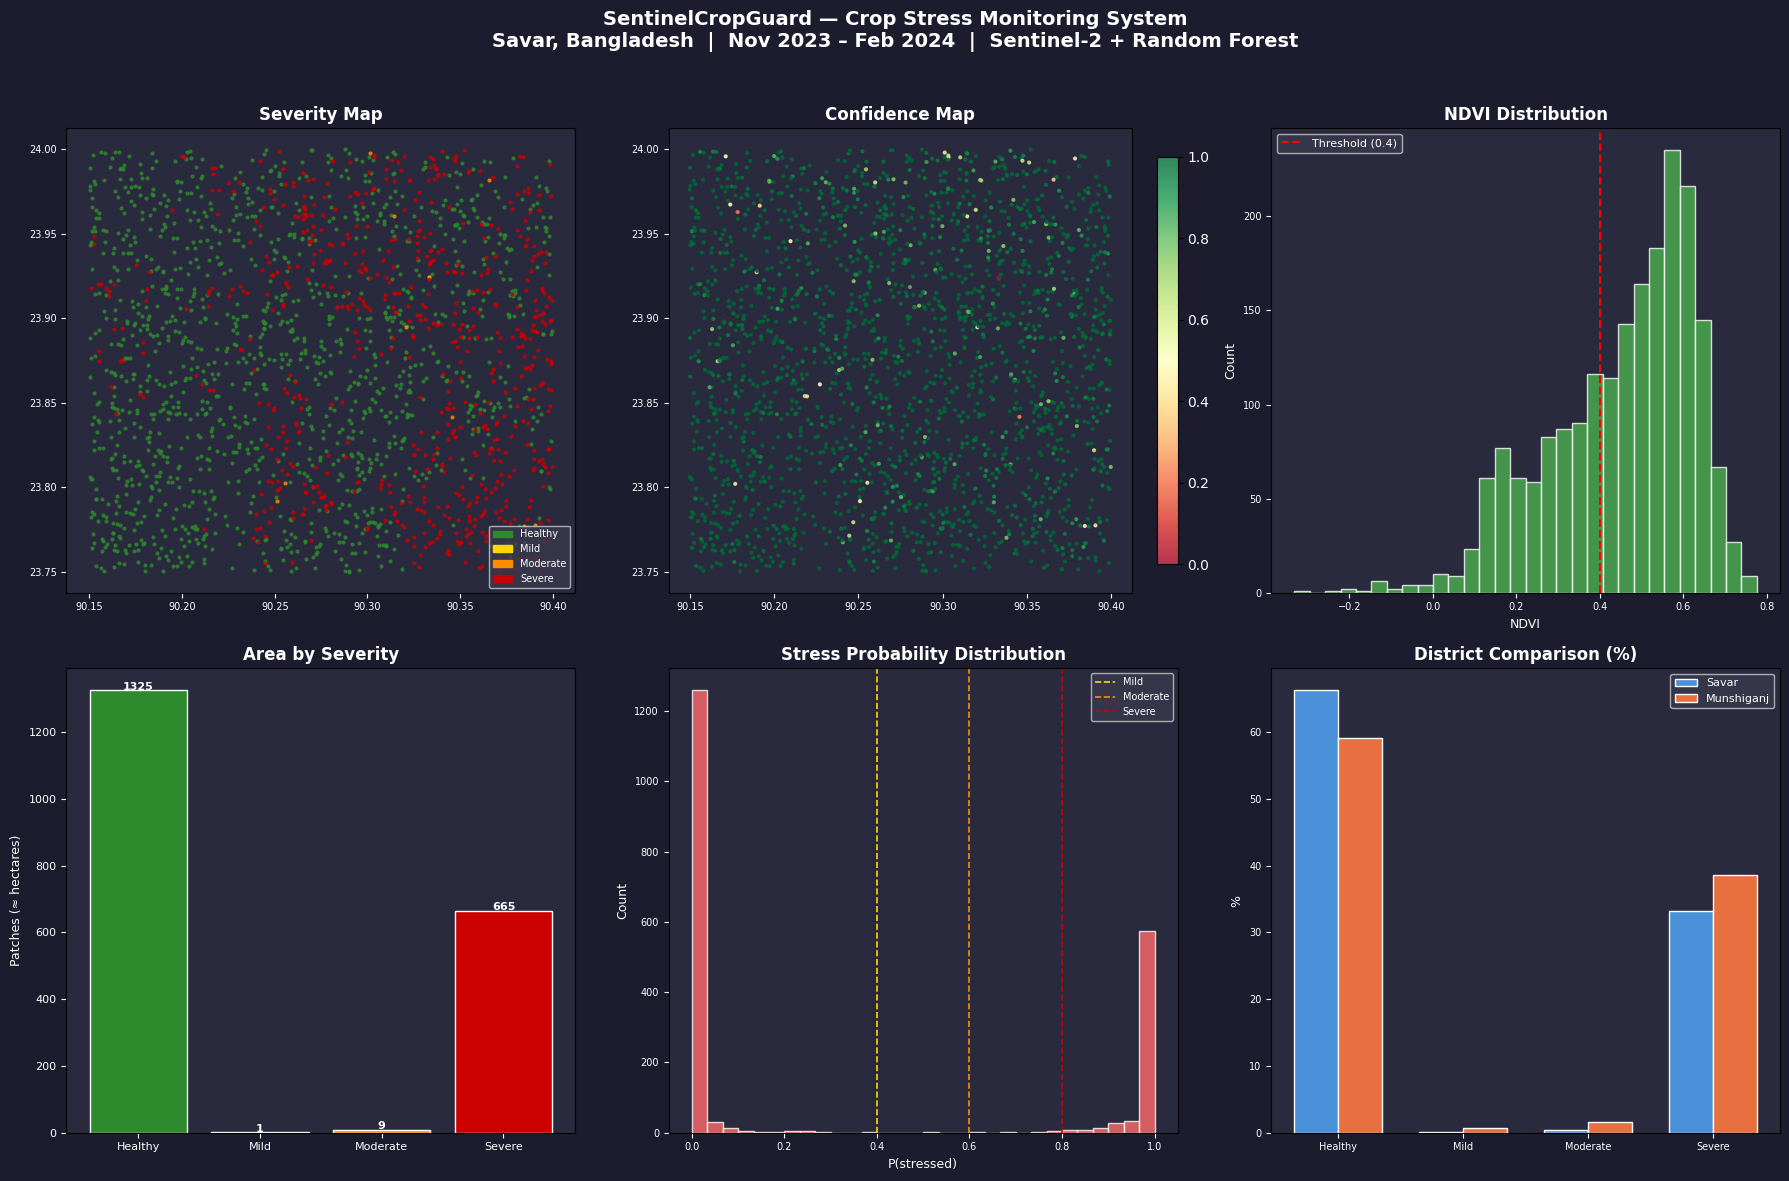

✅ Final dashboard saved as 'final_dashboard_week7.png'
   This is your Week 7 showcase image for your supervisor!


In [18]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#1C1C2E')

# ---- Title ----
fig.suptitle(
    'SentinelCropGuard — Crop Stress Monitoring System\n'
    'Savar, Bangladesh  |  Nov 2023 – Feb 2024  |  Sentinel-2 + Random Forest',
    fontsize=14, fontweight='bold', color='white', y=0.98
)

# ---- Plot 1: Severity Map ----
ax1 = fig.add_subplot(2, 3, 1)
ax1.set_facecolor('#2a2a3e')
for sev, cfg in SEVERITY_CONFIG.items():
    subset = grid_df[grid_df['severity'] == sev]
    if len(subset) > 0:
        ax1.scatter(subset['lon'], subset['lat'], c=cfg['color'], s=4, alpha=0.75)
ax1.set_title('Severity Map', color='white', fontweight='bold')
ax1.tick_params(colors='white', labelsize=7)
legend_patches = [mpatches.Patch(color=v['color'], label=k) for k, v in SEVERITY_CONFIG.items()]
ax1.legend(handles=legend_patches, fontsize=7, loc='lower right',
           framealpha=0.8, facecolor='#3a3a4e', labelcolor='white')

# ---- Plot 2: Confidence Map ----
ax2 = fig.add_subplot(2, 3, 2)
ax2.set_facecolor('#2a2a3e')
sc = ax2.scatter(grid_df['lon'], grid_df['lat'],
                 c=grid_df['confidence'], cmap='RdYlGn',
                 s=4, alpha=0.8, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax2, fraction=0.04).ax.tick_params(labelcolor='white')
ax2.set_title('Confidence Map', color='white', fontweight='bold')
ax2.tick_params(colors='white', labelsize=7)

# ---- Plot 3: NDVI Distribution ----
ax3 = fig.add_subplot(2, 3, 3)
ax3.set_facecolor('#2a2a3e')
ax3.hist(grid_df['ndvi_mean'], bins=30, color='#4CAF50', edgecolor='white', alpha=0.8)
ax3.axvline(x=0.4, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.4)')
ax3.set_xlabel('NDVI', color='white', fontsize=9)
ax3.set_ylabel('Count', color='white', fontsize=9)
ax3.set_title('NDVI Distribution', color='white', fontweight='bold')
ax3.tick_params(colors='white', labelsize=7)
ax3.legend(fontsize=8, facecolor='#3a3a4e', labelcolor='white')

# ---- Plot 4: Area Bar Chart ----
ax4 = fig.add_subplot(2, 3, 4)
ax4.set_facecolor('#2a2a3e')
sevs   = ['Healthy', 'Mild', 'Moderate', 'Severe']
counts = [savar_counts.get(s, 0) for s in sevs]
cols   = ['#2d8a2d', '#FFD700', '#FF8C00', '#CC0000']
bars   = ax4.bar(sevs, counts, color=cols, edgecolor='white')
for bar, cnt in zip(bars, counts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{cnt}', ha='center', color='white', fontsize=8, fontweight='bold')
ax4.set_ylabel('Patches (≈ hectares)', color='white', fontsize=9)
ax4.set_title('Area by Severity', color='white', fontweight='bold')
ax4.tick_params(colors='white', labelsize=8)

# ---- Plot 5: Probability Histogram ----
ax5 = fig.add_subplot(2, 3, 5)
ax5.set_facecolor('#2a2a3e')
ax5.hist(grid_df['prob_stressed'], bins=30, color='#FF6B6B', edgecolor='white', alpha=0.8)
for threshold, label_txt, col in [
    (0.4, 'Mild', '#FFD700'),
    (0.6, 'Moderate', '#FF8C00'),
    (0.8, 'Severe', '#CC0000')
]:
    ax5.axvline(x=threshold, color=col, linestyle='--', linewidth=1.2, label=label_txt)
ax5.set_xlabel('P(stressed)', color='white', fontsize=9)
ax5.set_ylabel('Count', color='white', fontsize=9)
ax5.set_title('Stress Probability Distribution', color='white', fontweight='bold')
ax5.tick_params(colors='white', labelsize=7)
ax5.legend(fontsize=7, facecolor='#3a3a4e', labelcolor='white')

# ---- Plot 6: District Comparison Bar ----
ax6 = fig.add_subplot(2, 3, 6)
ax6.set_facecolor('#2a2a3e')
x    = np.arange(len(sevs))
w    = 0.35
sv   = [savar_counts.get(s, 0) / len(grid_df) * 100  for s in sevs]
mu   = [munshi_counts.get(s, 0) / len(munshi_df) * 100 for s in sevs]
ax6.bar(x - w/2, sv, w, label='Savar',      color='#4A90D9', edgecolor='white')
ax6.bar(x + w/2, mu, w, label='Munshiganj', color='#E87040', edgecolor='white')
ax6.set_xticks(x)
ax6.set_xticklabels(sevs, color='white', fontsize=8)
ax6.set_ylabel('%', color='white', fontsize=9)
ax6.set_title('District Comparison (%)', color='white', fontweight='bold')
ax6.tick_params(colors='white', labelsize=7)
ax6.legend(fontsize=8, facecolor='#3a3a4e', labelcolor='white')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('final_dashboard_week7.png', dpi=150, bbox_inches='tight', facecolor='#1C1C2E')
plt.show()

print("✅ Final dashboard saved as 'final_dashboard_week7.png'")
print("   This is your Week 7 showcase image for your supervisor!")

---
## 📝 Step 12 — DAY 6: Write Your Progress Summary

Copy this and put it in your progress summary document:

In [19]:
print("=" * 60)
print("   WEEK 7 PROGRESS SUMMARY — SentinelCropGuard")
print("=" * 60)
print()
print("What we built this week:")
print()
print("1. SEVERITY CLASSIFICATION")
print("   Instead of binary (healthy/stressed), the model now")
print("   outputs 4 levels: Healthy, Mild, Moderate, Severe.")
print("   This is done using predict_proba() — the probability")
print("   that a patch is stressed.")
print()
print("2. CONFIDENCE MAP")
print("   We measure how SURE the model is about each prediction.")
print("   Confidence = |P(stressed) - 0.5| × 2")
print("   Low confidence zones need more ground-truth investigation.")
print()
print("3. AREA STATISTICS")
print(f"   Savar stressed area breakdown:")
for sev in ['Mild','Moderate','Severe']:
    ha = savar_counts.get(sev, 0)
    print(f"     {sev}: {ha} hectares ({ha/len(grid_df)*100:.1f}%)")
print()
print("4. DISTRICT COMPARISON")
print("   Same model tested on Munshiganj (never seen during training).")
print(f"   Savar stressed: {savar_stress_pct:.1f}%")
print(f"   Munshiganj stressed: {munshi_stress_pct:.1f}%")
print()
print("Limitation noted:")
print("   Labels are pseudo-labels (NDVI threshold rule).")
print("   No actual field disease data used yet.")
print("   This is appropriate for an early-warning stress detection system.")
print()
print("Next step: Week 8 — Deep Learning (CNN/ResNet) on patch images")
print("=" * 60)

   WEEK 7 PROGRESS SUMMARY — SentinelCropGuard

What we built this week:

1. SEVERITY CLASSIFICATION
   Instead of binary (healthy/stressed), the model now
   outputs 4 levels: Healthy, Mild, Moderate, Severe.
   This is done using predict_proba() — the probability
   that a patch is stressed.

2. CONFIDENCE MAP
   We measure how SURE the model is about each prediction.
   Confidence = |P(stressed) - 0.5| × 2
   Low confidence zones need more ground-truth investigation.

3. AREA STATISTICS
   Savar stressed area breakdown:
     Mild: 1 hectares (0.1%)
     Moderate: 9 hectares (0.4%)
     Severe: 665 hectares (33.2%)

4. DISTRICT COMPARISON
   Same model tested on Munshiganj (never seen during training).
   Savar stressed: 33.8%
   Munshiganj stressed: 40.8%

Limitation noted:
   Labels are pseudo-labels (NDVI threshold rule).
   No actual field disease data used yet.
   This is appropriate for an early-warning stress detection system.

Next step: Week 8 — Deep Learning (CNN/ResNet) on

---
## ✅ Week 7 Complete! What You Built

| What | Done |
|------|------|
| Severity function (4 levels) | ✅ |
| Probability-based prediction | ✅ |
| 4-color severity map | ✅ |
| Area per severity class (hectares) | ✅ |
| Confidence map | ✅ |
| District comparison (Savar vs Munshiganj) | ✅ |
| Final professional dashboard | ✅ |
| Progress summary written | ✅ |

